### Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 699.0 kB/s eta 0:02:25
   ---------------------------------------- 0.8/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 1.0/101.7 MB 949.8 kB/s eta 0:01:46
   ---------------------------------------- 1.0/101.7 MB 949.8 kB/s eta 0:01:46
    --------------------------------------- 1.6/101.7 MB 1.0 MB/s eta 0:01:38
    --------------------------------------- 1.8/101.7 MB 1.1 MB/s eta 0:01:33
    --------------------------------------- 2.1/101.7 MB 1.1 MB/s eta 0:01:32
    --------------------------------------- 2.4/101.7 MB 1.1 MB/s eta 0:01:27
   - --------


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

In [8]:
#Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###  Exploratory Data Analysis (EDA)

In [12]:
#Survival rate by class and gender
print(df.groupby(['Pclass','Sex'])['Survived'].mean())

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


In [13]:
#Missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


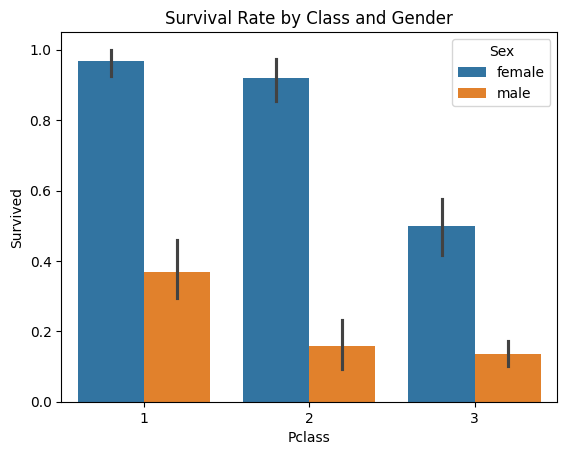

In [14]:
# Key insight plot
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title('Survival Rate by Class and Gender')
plt.savefig('survival_by_class.png', dpi=150)
plt.show()

### Feature Engineering

In [15]:
#Fill missing values
df['Age'].fillna(df['Age'].median(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

C:\Users\Nuwani Hitibandara\AppData\Local\Temp\ipykernel_29320\1654060730.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
C:\Users\Nuwani Hitibandara\AppData\Local\Temp\ipykernel_29320\1654060730.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [17]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [18]:
#Encode categorical variables
df['Sex']=LabelEncoder().fit_transform(df['Sex'])
df['Embarked']=LabelEncoder().fit_transform(df['Embarked'])

In [19]:
#New feature: family size and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] +1
df['IsAlone'] = (df['FamilySize']==1).astype(int)

In [21]:
#Train test split
X = df.drop('Survived', axis=1)
y=df['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [22]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,1,22.0,1,0,7.2500,2,2,0
1,1,0,38.0,1,0,71.2833,0,2,0
2,3,0,26.0,0,0,7.9250,2,1,1
3,1,0,35.0,1,0,53.1000,2,2,0
4,3,1,35.0,0,0,8.0500,2,1,1


In [23]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [24]:
#Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.fit_transform(X_test)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
331,1,1,45.5,0,0,28.5000,2,1,1
733,2,1,23.0,0,0,13.0000,2,1,1
382,3,1,32.0,0,0,7.9250,2,1,1
704,3,1,26.0,1,0,7.8542,2,2,0
813,3,0,6.0,4,2,31.2750,2,7,0


### Train all 3 models

In [28]:
models={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results={}

In [29]:
print(models.items())

dict_items([('Logistic Regression', LogisticRegression(max_iter=1000)), ('Random Forest', RandomForestClassifier(random_state=42)), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...))])


In [30]:
for name, model in models.items():
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        "Accuracy":accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba)
        
    }

results_df = pd.DataFrame(results).T
print(results_df)

C:\Users\Nuwani Hitibandara\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:37:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                     Accuracy  F1 Score   ROC-AUC
Logistic Regression  0.804469  0.748201  0.882754
Random Forest        0.815642  0.772414  0.892149
XGBoost              0.776536  0.729730  0.872973


### Visualize Results 

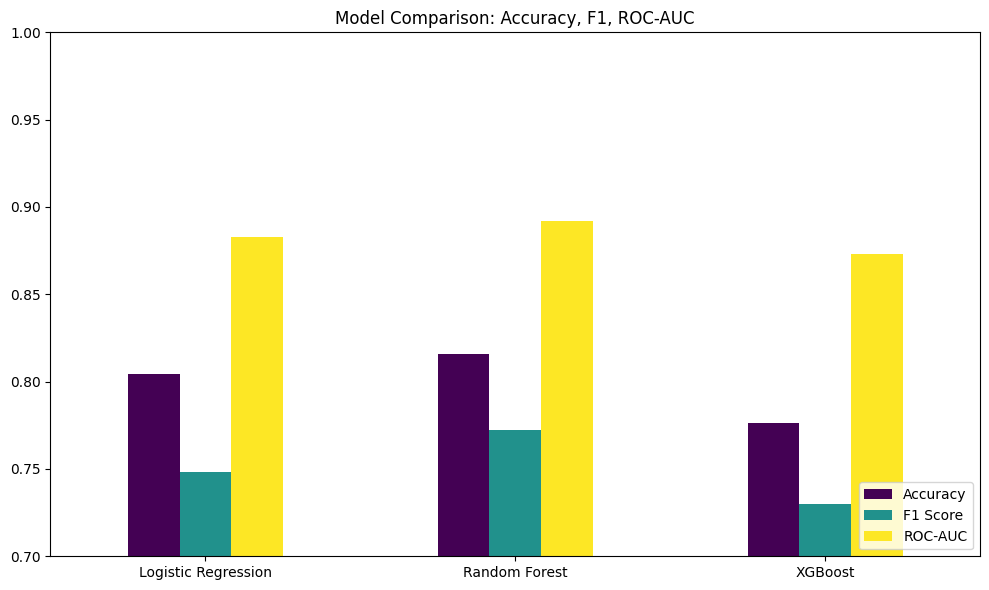

In [31]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Comparison: Accuracy, F1, ROC-AUC')
plt.xticks(rotation=0)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

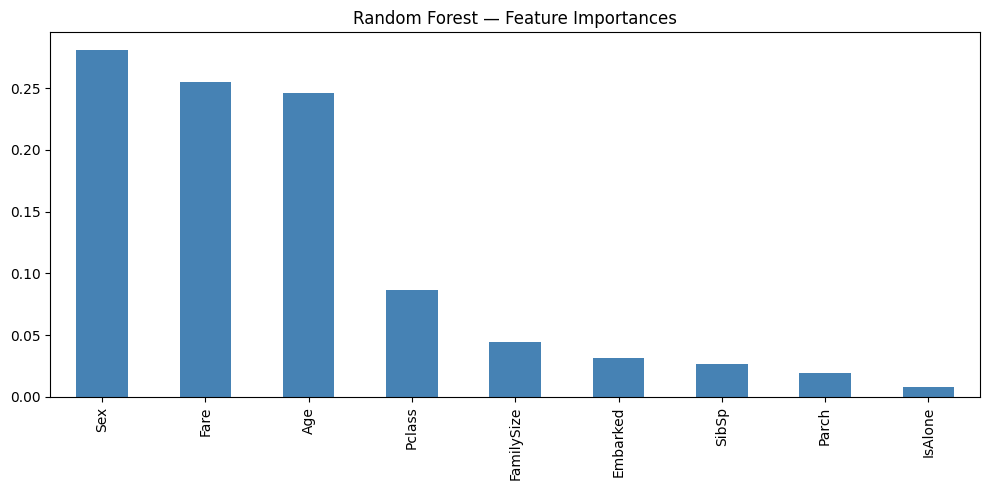

In [32]:
# Feature importance (Random Forest)
feat_imp = pd.Series(
    models["Random Forest"].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    X_cv = X_train_scaled if name == "Logistic Regression" else X_train
    cv_scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='roc_auc')
    print(f"{name}: CV ROC-AUC = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Logistic Regression: CV ROC-AUC = 0.8447 ± 0.0234
Random Forest: CV ROC-AUC = 0.8431 ± 0.0199


C:\Users\Nuwani Hitibandara\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:43:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Nuwani Hitibandara\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:43:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Nuwani Hitibandara\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:43:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Nuwani Hitibandara\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\traini

XGBoost: CV ROC-AUC = 0.8440 ± 0.0065
